In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, classification_report, 
                             confusion_matrix, roc_auc_score, f1_score, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter



from sklearn.model_selection import train_test_split, learning_curve

from sklearn.metrics import (accuracy_score, precision_score, recall_score, roc_auc_score, 
                            confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier, plot_importance
from sklearn.neural_network import MLPClassifier

# MLP

# Data preparation

In [2]:
train_df = pd.read_parquet('train_processed.parquet')
imp_features = pd.read_csv('feature_importances.csv')

columns_to_keep = imp_features['feature'].tolist() + ['TARGET']
selected_columns = train_df.columns[train_df.columns.isin(columns_to_keep)]
train_df_selected = train_df[selected_columns]

In [3]:
X = train_df_selected.drop('TARGET', axis=1)
y = train_df_selected['TARGET']

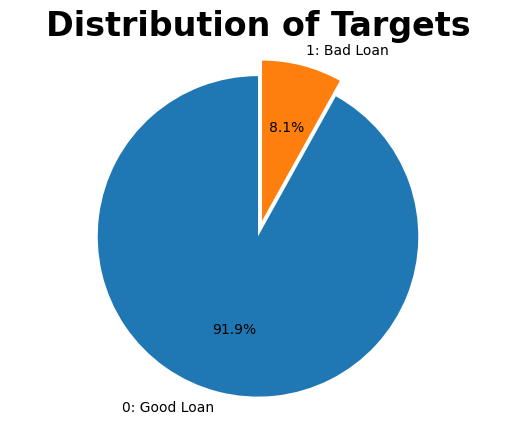

In [4]:
target_counts = y.value_counts()
sizes = [target_counts[0], target_counts[1]]

fig, ax = plt.subplots()
ax.pie(sizes, labels=['0: Good Loan', '1: Bad Loan'], autopct='%1.1f%%', startangle=90, explode=(0, 0.1))
ax.axis('equal')
plt.title('Distribution of Targets', fontsize=24, fontweight='bold')
plt.savefig('distr_initial.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
total_missing = X.isnull().sum().sum()
print(f"Total missing values: {total_missing}")

rows_with_nan = X.isnull().any(axis=1).sum()
print(f"Rows with NaN: {rows_with_nan}")

rows_complete = X.notnull().all(axis=1).sum()
print(f"Complete rows (no NaN): {rows_complete}")

print(f"Percentage of rows with NaN: {rows_with_nan/len(X)*100:.2f}%")

Total missing values: 2936809
Rows with NaN: 263668
Complete rows (no NaN): 43843
Percentage of rows with NaN: 85.74%


In [6]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

In [7]:
technique = SMOTEENN(sampling_strategy='minority',random_state=66)

X_resampled, y_resampled = technique.fit_resample(X_imputed, y)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.20, random_state=66)

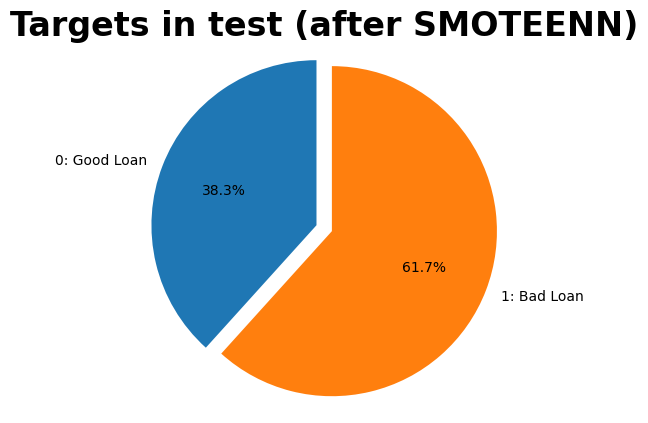

In [9]:
target_counts = y_test.value_counts()
sizes = [target_counts[0], target_counts[1]]

fig, ax = plt.subplots()
ax.pie(sizes, labels=['0: Good Loan', '1: Bad Loan'], autopct='%1.1f%%', startangle=90, explode=(0, 0.1))
ax.axis('equal')
plt.title('Targets in test (after SMOTEENN)', fontsize=24, fontweight='bold')
plt.savefig('distr_smoteenn.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
technique = SMOTE(sampling_strategy='minority',random_state=66)

X_resampled, y_resampled = technique.fit_resample(X_imputed, y)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.20, random_state=66)

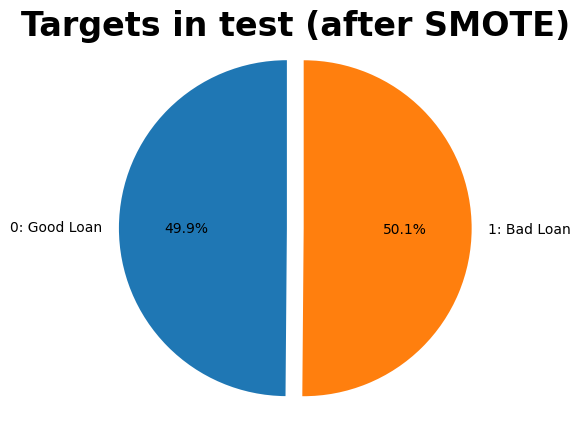

In [12]:
target_counts = y_test.value_counts()
sizes = [target_counts[0], target_counts[1]]

fig, ax = plt.subplots()
ax.pie(sizes, labels=['0: Good Loan', '1: Bad Loan'], autopct='%1.1f%%', startangle=90, explode=(0, 0.1))
ax.axis('equal')
plt.title('Targets in test (after SMOTE)', fontsize=24, fontweight='bold')

plt.savefig('distr_smote.png', dpi=300, bbox_inches='tight')
plt.show()

# MLP optimal parameter search

In [13]:
from sklearn.neural_network import MLPClassifier

In [14]:
mlp_model = MLPClassifier(activation='relu', alpha=0.001, batch_size='auto', early_stopping=True,
                          hidden_layer_sizes=(200, 200, 150, 150), learning_rate='adaptive', solver='adam',
                          random_state=66)

mlp_model.fit(X_train, y_train)
mlp_y_pred_proba = mlp_model.predict_proba(X_test)[:, 1]
mlp_y_pred = mlp_model.predict(X_test)

In [15]:
mlp_accuracy = accuracy_score(y_test, mlp_y_pred)
mlp_precision = precision_score(y_test, mlp_y_pred)
mlp_recall = recall_score(y_test, mlp_y_pred)
mlp_f1 = f1_score(y_test, mlp_y_pred)
mlp_auc_roc = roc_auc_score(y_test, mlp_y_pred_proba)
mlp_cm = confusion_matrix(y_test, mlp_y_pred)

print("MLP Classifier:")
print(f"Accuracy: {mlp_accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall: {mlp_recall:.4f}")
print(f"F1-score: {mlp_f1:.4f}")
print(f"AUC-ROC: {mlp_auc_roc:.4f}")

print("Confusion Matrix:")
print(mlp_cm)

MLP Classifier:
Accuracy: 0.5245
Precision: 0.5145
Recall: 0.9161
F1-score: 0.6589
AUC-ROC: 0.5262
Confusion Matrix:
[[ 7383 49007]
 [ 4758 51927]]


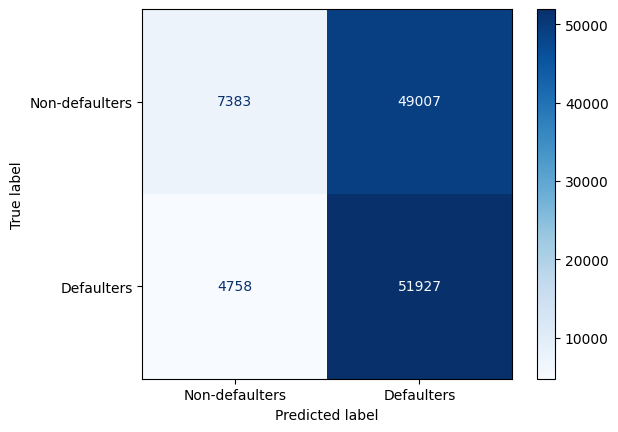

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix=mlp_cm, display_labels=['Non-defaulters', 'Defaulters'])
disp.plot(cmap=plt.cm.Blues)
# plt.savefig('confusion_matrix_MLP.png', dpi=300, bbox_inches='tight')  
plt.show()

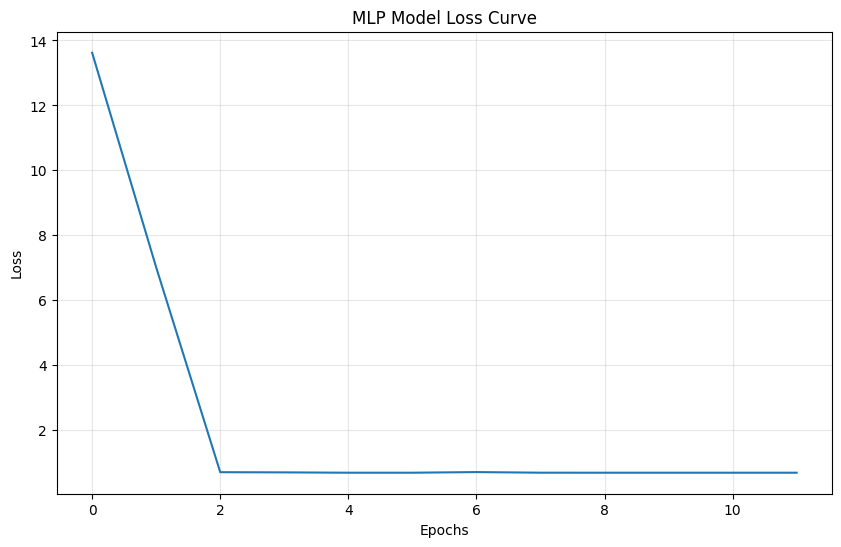

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(mlp_model.loss_curve_)
plt.title('MLP Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# plt.savefig('loss_MLP.png', dpi=300, bbox_inches='tight') 
plt.show()